In [31]:
from tensorflow.keras import mixed_precision

# Enable mixed precision for faster training on Tesla T4 GPU
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [49]:
import tensorflow as tf
import os

SEED=42
tf.random.set_seed(SEED)

IMG_SIZE=(224,224)
BATCH_SIZE=64


DATASET_PATH="/kaggle/input/balanced-dataset-of-pest/Balanced_Dataset_Of_Pest"

In [50]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 8400 files belonging to 12 classes.
Using 6720 files for training.
Found 8400 files belonging to 12 classes.
Using 1680 files for validation.


In [51]:
val_batches = int(0.5 * tf.data.experimental.cardinality(val_test_ds).numpy())
val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)


In [52]:
class_names=train_ds.class_names
NUM_CLASSES=len(class_names)

print("Classes: ", class_names)
print("Total classes: ",NUM_CLASSES)

Classes:  ['aphids', 'beetle', 'bollworm', 'bugs', 'catterpillar', 'earwig', 'grasshopper', 'mites', 'slug', 'snail', 'weevil', 'whitefly']
Total classes:  12


In [53]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


In [54]:
from tensorflow.keras import layers

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.20),
    #layers.RandomBrightness(0.20),
],name="data_augmentation")

In [55]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


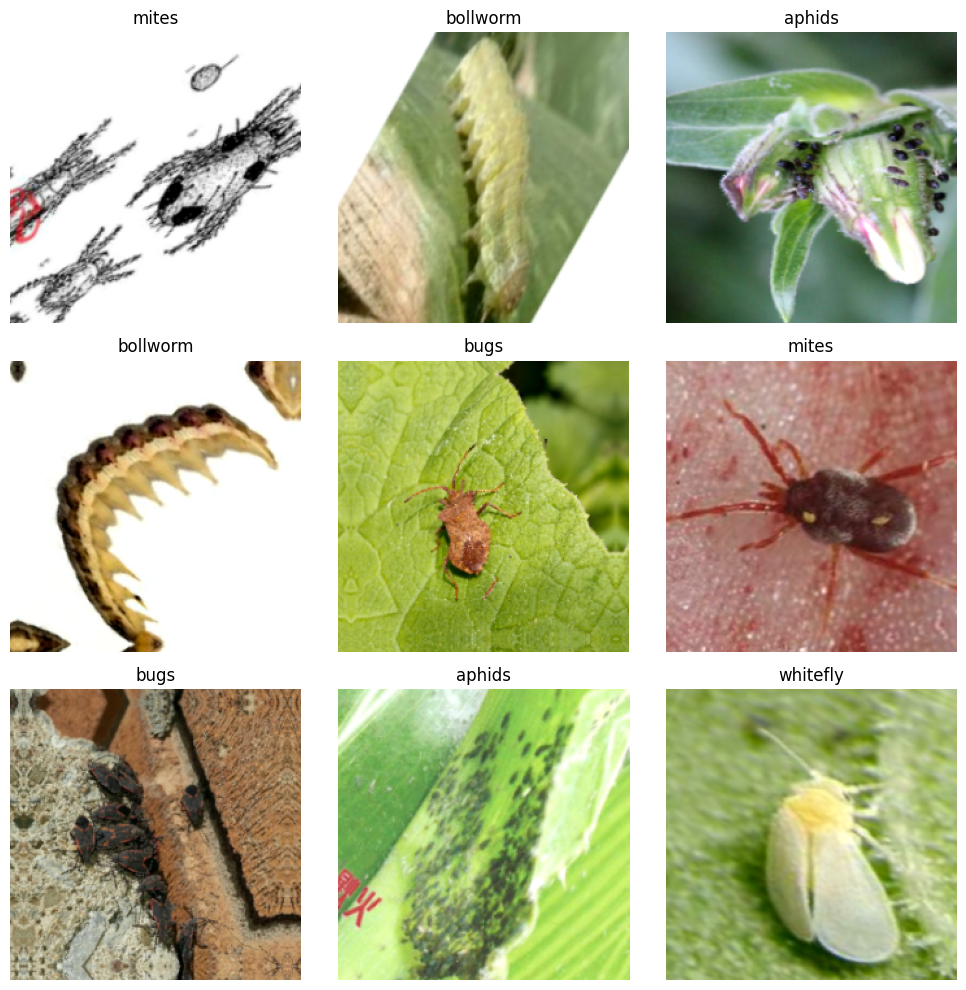

In [56]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Get a batch
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    
    # 1. Cast to float32 (Matplotlib doesn't support float16)
    img = tf.cast(image_batch[i], tf.float32)
    
    # 2. Clip values to [0, 1] if they are floats
    # Note: If your images are still in [0, 255], divide by 255.0 here
    img = tf.clip_by_value(img / 255.0, 0.0, 1.0) 
    
    plt.imshow(img.numpy())
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Found 8400 files belonging to 12 classes.


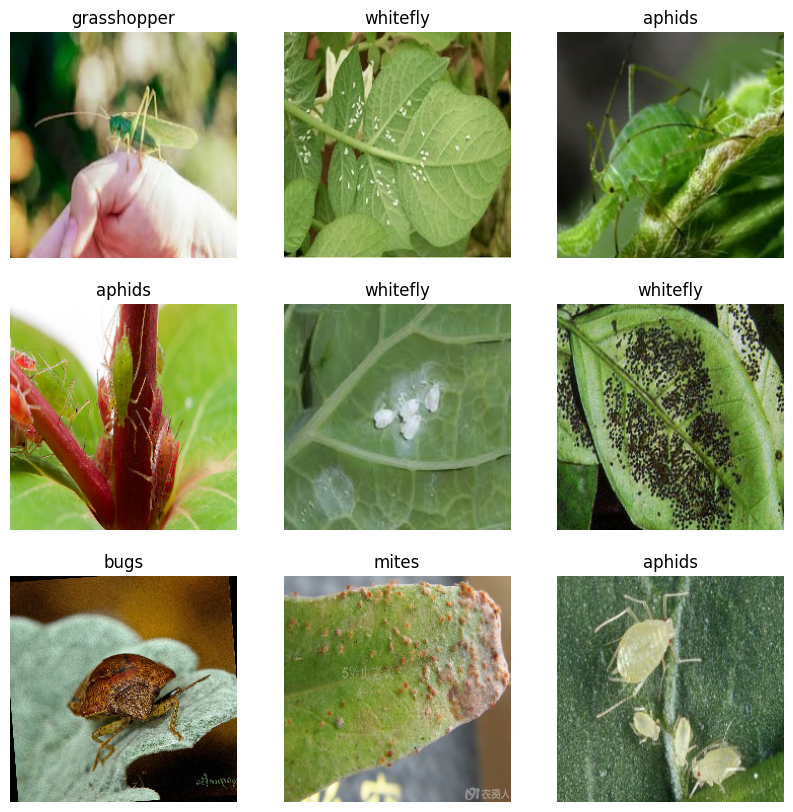

In [57]:
raw_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=9,
    shuffle=True
)

raw_images, raw_labels = next(iter(raw_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(raw_images[i].numpy().astype("uint8"))
    plt.title(class_names[raw_labels[i]])
    plt.axis("off")


In [58]:
import tensorflow as tf
from tensorflow.keras import layers, models

#Define Convolution Block
#Purpose
#Extract spatial features (edges, body shapes, texture)

def conv_block(x, filters, kernel_size=3, strides=1):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

#Define Squeeze-and-Excitation (SE) Block

#Purpose

#Emphasize important pest features

#Suppress background noise

def se_block(x, reduction=16):
    channels = x.shape[-1]
    
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    
    return layers.Multiply()([x, se])


In [66]:
import tensorflow as tf
from tensorflow.keras import layers, models

def squeeze_excitation_block(input_tensor, ratio=16):
    """Adds channel attention to the feature maps."""
    init = input_tensor
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape(se_shape)(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    return layers.multiply([init, se])


def residual_block(x, filters, kernel_size=3):
    shortcut = x
    
    # First Convolution
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x) # Swish is often better than ReLU for deep nets
    
    # Second Convolution
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # If the number of filters changed, adjust the shortcut
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # The Skip Connection (Addition)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)
    return x

def PestNet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Scaling and Initial Stem
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(32, 7, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x) # Changed to swish
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # 2. Sequential Residual + SE Blocks
    for filters in [64, 128, 256, 512]:
        x = residual_block(x, filters)
        x = se_block(x)
        x = layers.MaxPooling2D()(x)

    # 3. Final Global Processing
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="swish")(x)
    x = layers.Dropout(0.4)(x) 
    
    # Corrected 'num_classes' variable here
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='predictions')(x)

    return models.Model(inputs, outputs, name="PestNet_Scratch")

In [67]:
model = PestNet(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

model.summary()


Model: "PestNet_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 112, 112,  │      4,704 │ rescaling_4[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 56, 56,    │          0 │ activation_24[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 56, 56,    │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 56, 56,    │     36,928 │ activation_25[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 56, 56,    │      2,112 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 56, 56,    │          0 │ add_16[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_26[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 4)         │        260 │ global_average_p

 Total params: 5,206,824 (19.86 MB)

 Trainable params: 5,201,000 (19.84 MB)

 Non-trainable params: 5,824 (22.75 KB)

In [73]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), # Start higher
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)


In [74]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [75]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)


In [76]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_pestnet.keras",
    monitor="val_accuracy",
    save_best_only=True
)


In [77]:
EPOCHS = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 77s 387ms/step - accuracy: 0.1701 - loss: 2.4667 - val_accuracy: 0.0889 - val_loss: 3.1268 - learning_rate: 0.0010
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 366ms/step - accuracy: 0.3005 - loss: 2.0572 - val_accuracy: 0.0938 - val_loss: 2.9816 - learning_rate: 0.0010
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 365ms/step - accuracy: 0.3739 - loss: 1.8438 - val_accuracy: 0.1430 - val_loss: 3.1598 - learning_rate: 0.0010
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 370ms/step - accuracy: 0.4366 - loss: 1.6818 - val_accuracy: 0.2788 - val_loss: 2.3082 - learning_rate: 0.0010
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 39s 362ms/step - accuracy: 0.4822 - loss: 1.5295 - val_accuracy: 0.2404 - val_loss: 2.6052 - learning_rate: 0.0010
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 365ms/step - accuracy: 0.5101 - loss: 1.4812 - val_accuracy: 0.3341 - val_loss: 2.2829 - learning_rate: 0.0010
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 371ms/step - accura

In [ ]:
model = tf.keras.models.load_model("best_pestnet.keras")


In [78]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 296ms/step - accuracy: 0.7317 - loss: 1.0479
Test Accuracy: 73.82%
Test Loss: 0.9749


In [79]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<Figure size 1000x1000 with 0 Axes>

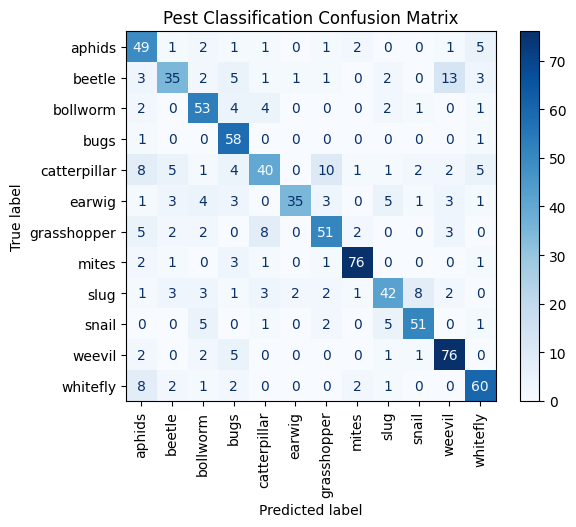

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Pest Classification Confusion Matrix")
plt.show()


In [81]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)


              precision    recall  f1-score   support

      aphids       0.60      0.78      0.68        63
      beetle       0.67      0.53      0.59        66
    bollworm       0.71      0.79      0.75        67
        bugs       0.67      0.97      0.79        60
catterpillar       0.68      0.51      0.58        79
      earwig       0.92      0.59      0.72        59
 grasshopper       0.72      0.70      0.71        73
       mites       0.90      0.89      0.90        85
        slug       0.71      0.62      0.66        68
       snail       0.80      0.78      0.79        65
      weevil       0.76      0.87      0.81        87
    whitefly       0.77      0.79      0.78        76

    accuracy                           0.74       848
   macro avg       0.74      0.74      0.73       848
weighted avg       0.75      0.74      0.73       848



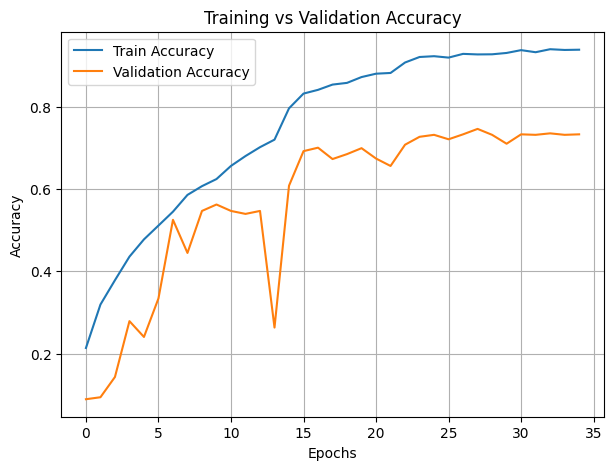

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()
